In [1]:
import os
import pickle
import sys
sys.path.append("/data1/morrisq/divyak/projects/metient/notebooks/lineage_tracing")
import lineage_tracing_utilities as lt
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

output_dir = "/data1/morrisq/divyak/projects/metient/notebooks/outputs"

# Change this to where reproducibility data is stored (Download here: https://github.com/divyakoyy/metient_reproducibility)
DATA_DIR = "/data1/morrisq/divyak/data/metient_reproducibility/lung_lineage_tracing"

metient_results_dir = os.path.join(DATA_DIR, "metient_outputs")

### Visualize a labeling from Fitch-Hartigan small parsimony solution for clone 99

DiGraph with 43 nodes and 42 edges
Total migrations: 8
mig_graph_no_diag
 tensor([[0., 0., 0., 0., 1., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0.],
        [1., 0., 2., 2., 0., 0.],
        [0., 0., 0., 0., 0., 0.]])


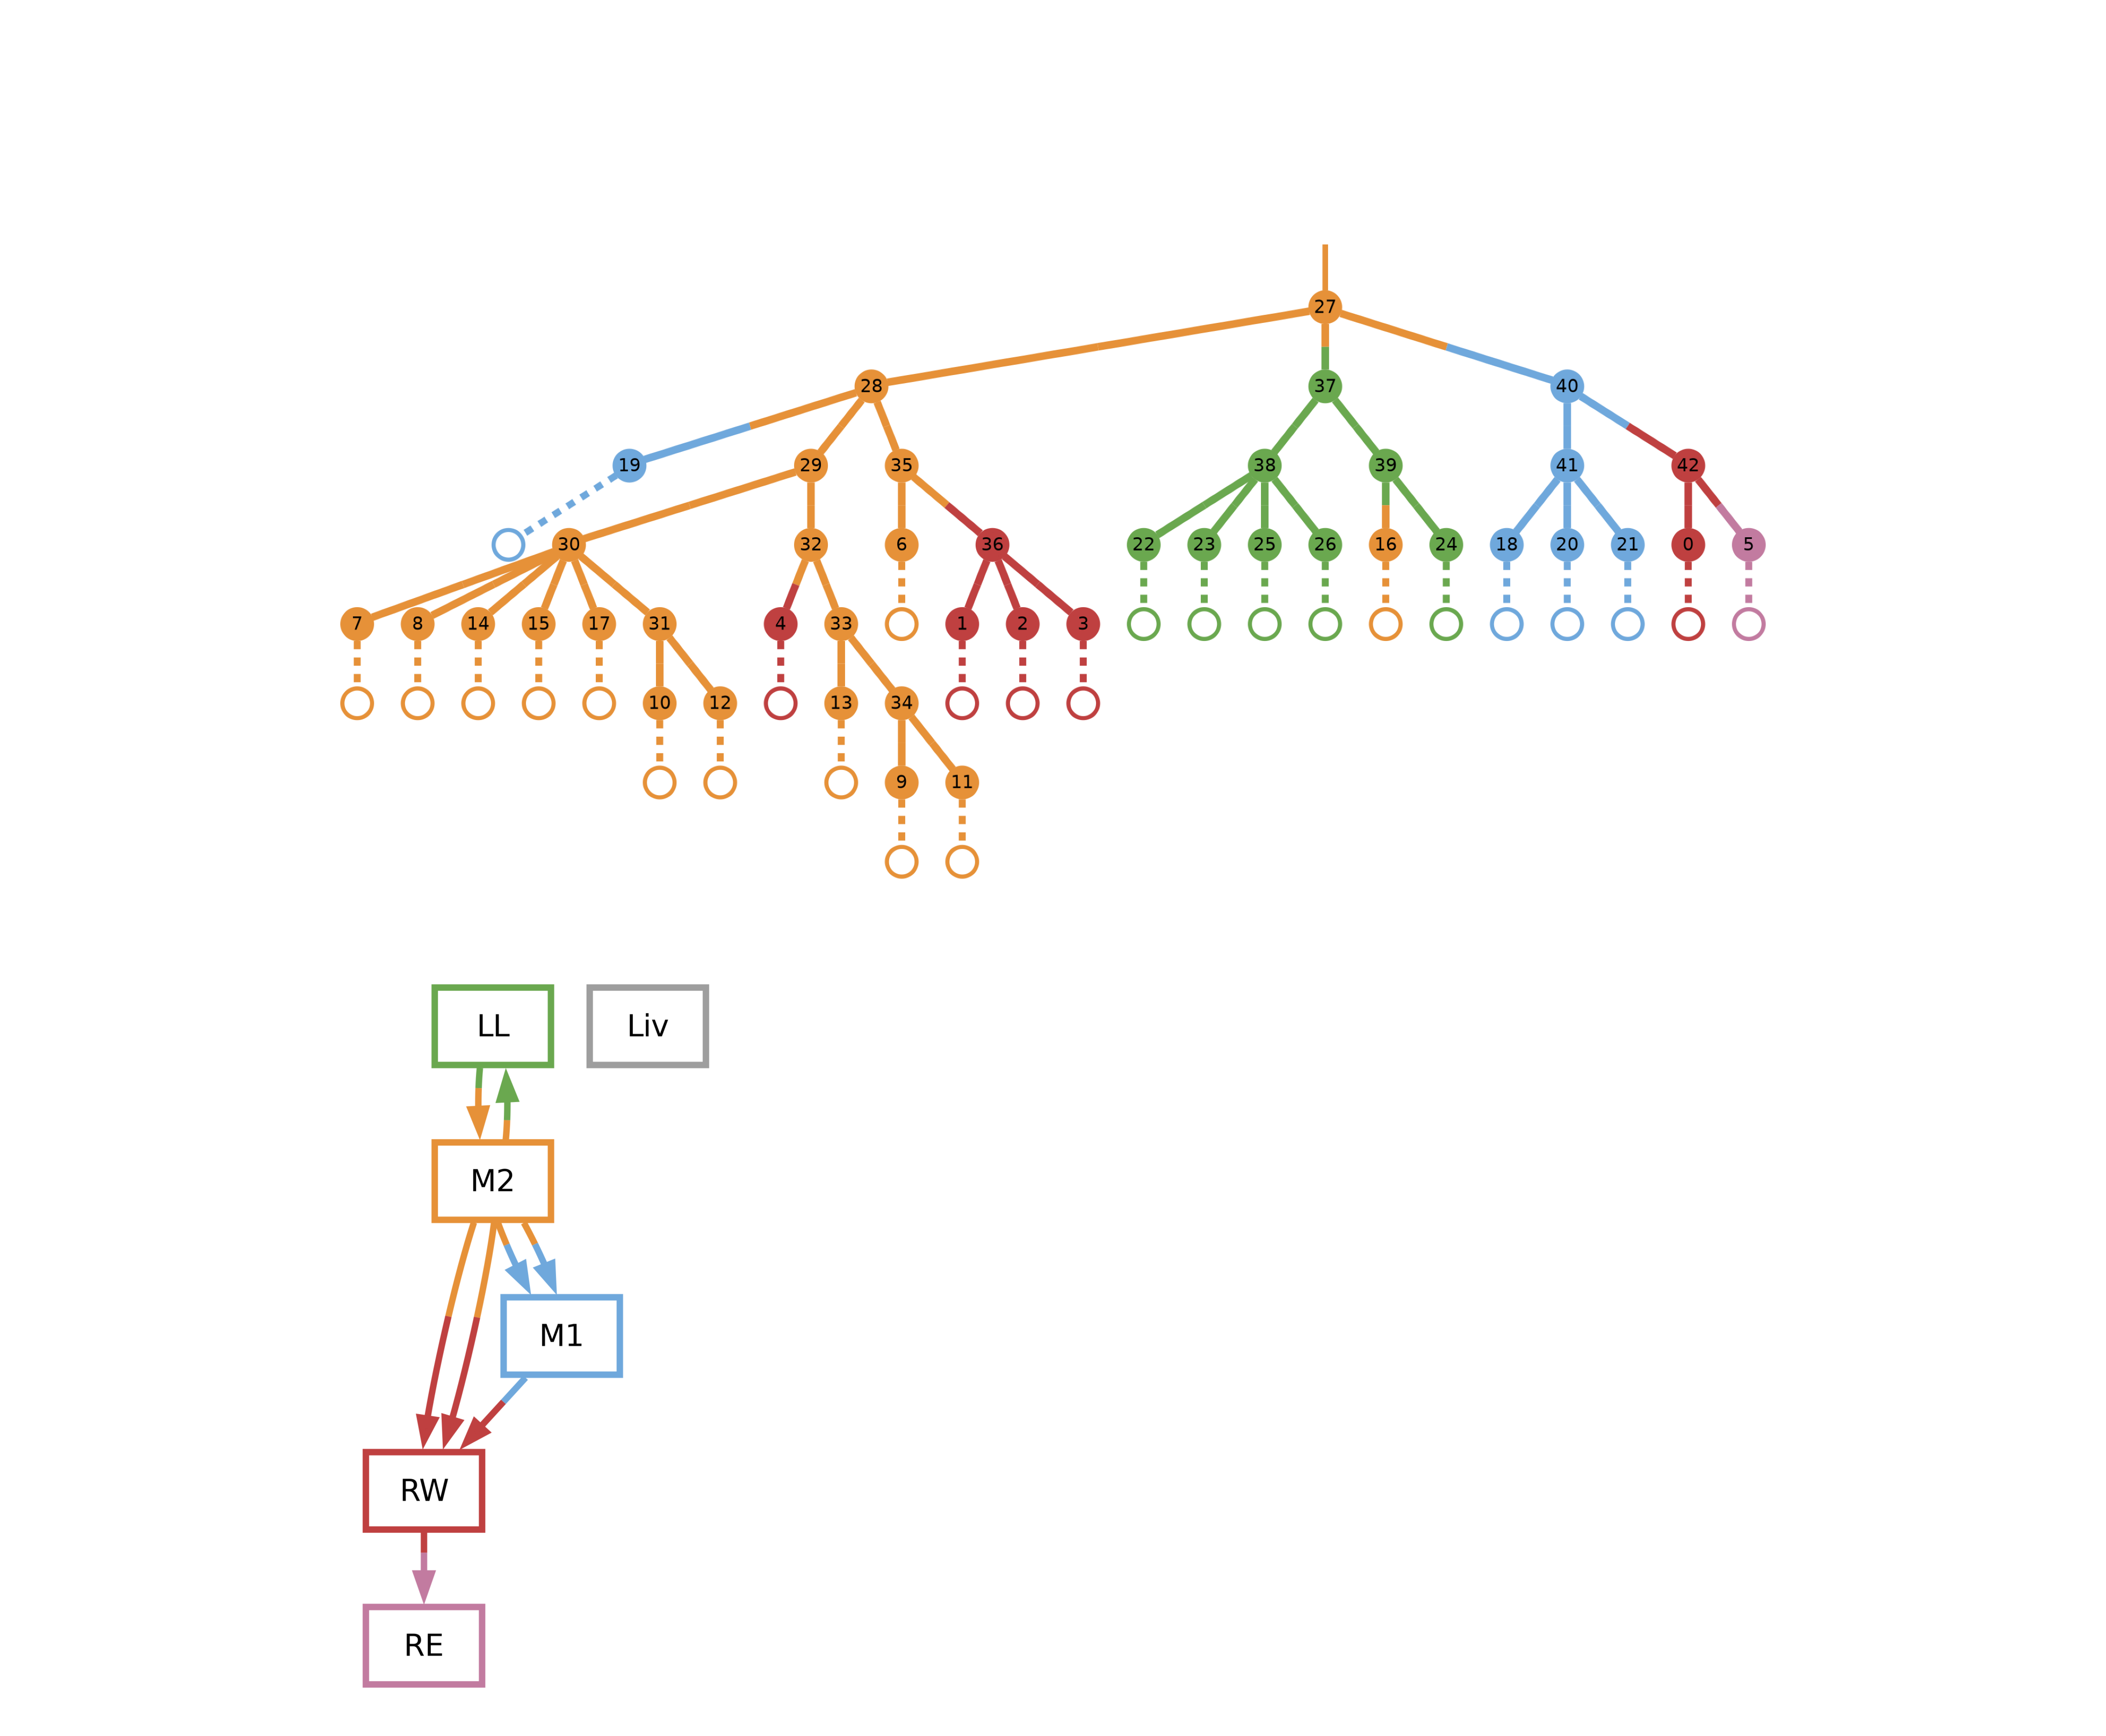

In [2]:
cass_results_dir = os.path.join(DATA_DIR, "cassiopeia_outputs")

with open(os.path.join(cass_results_dir,'vanilla_greedy_cas_random_min_mig_history.pkl'), 'rb') as f:
    fitch_min_mig_history = pickle.load(f)

clone=99
with open(os.path.join(cass_results_dir,f'{clone}_vanilla_cas_networkx.pkl'), 'rb') as f:
    G = pickle.load(f)
G.remove_node("primary")
print(G)
lt.plot_nx_tree(fitch_min_mig_history[clone], G, f"{clone}_fitch_count_random_history")

### Load migration histories

In [3]:
import gzip
import numpy.core.numeric
# alias old module path → new one
sys.modules['numpy._core.numeric'] = numpy.core.numeric

clones = [int(f[:-len('_LL.pkl.gz')]) for f in os.listdir(metient_results_dir) if f.endswith('_LL.pkl.gz')]
clones = sorted(clones)
print(len(clones), "clones")

def consensus_migration_graph_over_clones(scaled_migration_graphs):
    # Sum all normalized migration graphs with equal weights
    consensus_migrations = torch.zeros_like(scaled_migration_graphs[0])
    for graph in scaled_migration_graphs:
        consensus_migrations += graph
    
    # Normalize by dividing by total sum to make everything sum to 1
    total_sum = consensus_migrations.sum()
    # Handle case where sum is 0 to avoid division by zero
    total_sum = total_sum if total_sum != 0 else 1.0
    consensus_migrations = consensus_migrations / total_sum
    return consensus_migrations

with open(os.path.join(cass_results_dir,'vanilla_greedy_cas_unnormalized_tissue_transitions.pkl'), 'rb') as f:
    fitch_tissue_trans_data = pickle.load(f)

with open(os.path.join(cass_results_dir,'vanilla_greedy_cas_min_mig_score.pkl'), 'rb') as f:
    fitch_min_mig_scores = pickle.load(f)

clone_to_metient_tree_met_rate = {}
clone_to_fitch_tree_met_rate = {}

for clone in fitch_min_mig_scores:
    with open(os.path.join(cass_results_dir,f'{clone}_vanilla_cas_networkx.pkl'), 'rb') as f:
        G = pickle.load(f)
    edges = G.number_of_edges()
    clone_to_fitch_tree_met_rate[clone] = fitch_min_mig_scores[clone]/edges

met_scaled_migration_graphs = []
fitch_scaled_migration_graphs = []
for clone in clones:
    print(f"\nclone {clone}")

    _, weighted_scaled_tissue_trans, pars_metrics, mig_graphs = lt.extract_info(metient_results_dir, clone)
    with open(os.path.join(cass_results_dir,f'{clone}_vanilla_cas_networkx.pkl'), 'rb') as f:
        G = pickle.load(f)
    
    edges = G.number_of_edges()
    clone_to_metient_tree_met_rate[clone] = pars_metrics[0][0]/edges
    
    met_scaled_migration_graphs.append(weighted_scaled_tissue_trans)

    fitch_tissue_trans = lt.extract_scaled_fitch_tissue_trans(fitch_tissue_trans_data, clone)
    fitch_scaled_migration_graphs.append(fitch_tissue_trans)

met_consensus_migrations = consensus_migration_graph_over_clones(met_scaled_migration_graphs)
fitch_consensus_migrations = consensus_migration_graph_over_clones(fitch_scaled_migration_graphs)

100 clones

clone 1


/data1/morrisq/divyak/conda_envs/met3/lib/python3.14/site-packages/metient/util/data_extraction_util.py:35: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  parents = torch.tensor(parents)[mask]



clone 2

clone 3

clone 4

clone 5

clone 6

clone 7

clone 8

clone 9

clone 10

clone 11

clone 12

clone 13

clone 14

clone 15

clone 16

clone 17

clone 18

clone 19

clone 20

clone 21

clone 22

clone 23

clone 24

clone 25

clone 26

clone 27

clone 28

clone 29

clone 30

clone 31

clone 32

clone 33

clone 34

clone 35

clone 36

clone 37

clone 38

clone 39

clone 40

clone 41

clone 42

clone 43

clone 44

clone 45

clone 46

clone 47

clone 48

clone 49

clone 50

clone 51

clone 52

clone 53

clone 54

clone 55

clone 56

clone 57

clone 58

clone 59

clone 60

clone 61

clone 62

clone 63

clone 64

clone 65

clone 66

clone 67

clone 68

clone 69

clone 70

clone 71

clone 72

clone 73

clone 74

clone 75

clone 76

clone 77

clone 78

clone 79

clone 80

clone 81
No fitch tissue trans for clone 81

clone 82

clone 83

clone 84

clone 85

clone 86

clone 87

clone 88

clone 89

clone 90

clone 91

clone 92

clone 93

clone 94

clone 95

clone 96

clone 97

clone 98

cl

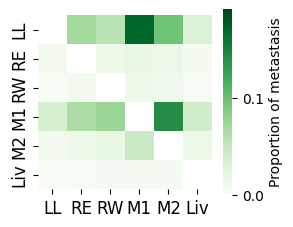

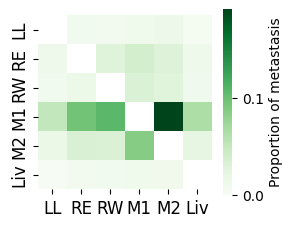

In [4]:
import math
def plot_overall_tissue_transiton(tissue_trans, max_val, method):
    # Overall tissue transition matrix
    tissue_trans = tissue_trans.clone()
    tissue_trans.fill_diagonal_(float('nan'))

    fig = plt.figure(figsize = (3,3))
    rounded_max_val = round(max_val * 20) / 20
    g = sns.heatmap(tissue_trans, cmap="Greens", square=True, vmin=0, vmax=max_val, 
                    cbar=True, cbar_kws={"label": "Proportion of metastasis", "ticks": [0, rounded_max_val/2, rounded_max_val], "shrink": 0.7})
    g.set_xticks([x+0.5 for x in range(len(lt.TISSUE_ORDER))],lt.TISSUE_ORDER, fontsize=12)
    g.set_yticks([x+0.5 for x in range(len(lt.TISSUE_ORDER))],lt.TISSUE_ORDER, fontsize=12)
    plt.subplots_adjust(hspace=0.7, wspace=0.1)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"consensus_migrations_{method}.svg"), dpi=500)
    plt.show()
    plt.close()

max_val = float(max(torch.max(met_consensus_migrations), torch.max(fitch_consensus_migrations)))
print()
plot_overall_tissue_transiton(met_consensus_migrations, max_val, "metient")
plot_overall_tissue_transiton(fitch_consensus_migrations, max_val, "fitch")
   
